<a href="https://colab.research.google.com/github/francobarrionuevoenv21/MAIE_devs_pub/blob/main/procs_goes_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)
# https://drive.google.com/file/d/19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8/view?usp=sharing # NOTE: Data is hosted in my drive folder. If broken, contact to francod.barrionuevo@gmail.com
!gdown --id 19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8

In [2]:
# Unzip folder with GOES bands 1-7 data
!unzip -qq data_GOES_tp.zip

In [11]:
# Import libraries and install depedencies
import xarray as xr

! pip install rioxarray
import rioxarray

import numpy as np
from matplotlib import pyplot as plt

import rasterio as rt
from rasterio.plot import show
from rasterio.crs import CRS
from rasterio.enums import Resampling

import os

In [12]:
# Define folder path
directory_path = '/content/drive-download-20260330T121459Z-1-001/'

# List all files in the directory
all_files = os.listdir(directory_path)

# Sort the paths
all_filles_sorted = []

for b in range(len(all_files)):
  for p in all_files:
    if int(p[20]) == (b+1):
      all_filles_sorted.append(p)

In [3]:
# Visualize and check files path sorting
all_filles_sorted

['OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc',
 'OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc',
 'OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc',
 'OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc',
 'OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc',
 'OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc',
 'OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc']

In [13]:
# Open and explore variables and metadata
band_org = xr.open_dataset(directory_path+all_filles_sorted[0]) # open band 1 for visualization of full disk

band_org # check bands and metadata

<xarray.Dataset> Size: 942MB
Dimensions:                                           (y: 10848, x: 10848,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 43kB 0.1519...
  * x                                                 (x) float32 43kB -0.151...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    band_id                                           (band) int8 1B ...
    band_wavelength                                   (band) float32 4B ...
    t                                                 datetime64[ns] 8B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                num_star_looks, band
Data variables: (12/37)
    Rad                                               (y, x) float32 471MB ...
    DQF                                               (y, x) float32 471MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:56.2Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        694ade65-94ac-4ea5-a8dc-4667e917a3fb

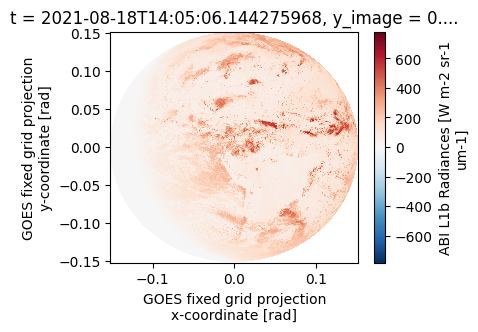

In [ ]:
# Plot full disk band 1
fig, ax = plt.subplots(figsize=(4, 3))
band_org.Rad.plot(ax=ax) # plot radiance

In [14]:
# Select bounding box limits including South America area
xmin, xmax = -0.025, 0.11
ymin, ymax = 0.04, -0.15

## Bands 1-6 to reflectance and plot RGB

In [15]:
# Resampling bands function
def resampling_xarray(band_org, band_res):

    if band_org.rio.shape != band_res.rio.shape:
        return band_res.rio.reproject_match(
            band_org,
            resampling=Resampling.bilinear # search the documentation for other resampling methods
        )
    else:
        return band_res

In [16]:
# Extract radiance data, compute reflectance and store them in a NxMxT array

listBands_refls = []
band_org = xr.open_dataset(directory_path+all_filles_sorted[0], decode_coords="all") # Set band 1 (1 km of spatial resolution) as the reference
band_org = band_org.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))

for b in range(6): # bands 1 to 6
  print(all_filles_sorted[b])
  goes_band = xr.open_dataset(directory_path+all_filles_sorted[b], decode_coords="all")
  goes_band = goes_band.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))
  rad_to_ref = goes_band.Rad*goes_band.kappa0
  rad_to_ref = rad_to_ref.rio.write_crs(goes_band.Rad.rio.crs) # explicitly set the CRS for rad_to_ref
  print('Input shape:', rad_to_ref.shape)
  band_res = resampling_xarray(band_org, rad_to_ref)
  print('Output shape:', band_res.shape)
  listBands_refls.append(band_res.values)

arrayBands_refls = np.array(listBands_refls)

OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc
Input shape: (6786, 4822)
Output shape: (6786, 4822)
OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc
Input shape: (13571, 9643)
Output shape: (6786, 4822)
OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc
Input shape: (6786, 4822)
Output shape: (6786, 4822)
OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc
Input shape: (3393, 2410)
Output shape: (6786, 4822)
OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc
Input shape: (6786, 4822)
Output shape: (6786, 4822)
OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc
Input shape: (3393, 2410)
Output shape: (6786, 4822)


In [17]:
# Store reflectance bands in a xarray dataset
bands1to6_reflc = xr.Dataset(coords=band_org.coords, attrs=band_org.attrs)

for b in range(len(listBands_refls)):
  bands1to6_reflc[f'band{b+1}_refl'] =  xr.DataArray(arrayBands_refls[b], coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
  bands1to6_reflc[f'band{b+1}_refl'] = bands1to6_reflc[f'band{b+1}_refl'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
#bands1to6_reflc

# Compute and store pseudo-green band
bands1to6_reflc[f'bandSG_refl'] =  xr.DataArray(0.45*arrayBands_refls[1] + 0.1*arrayBands_refls[2] + 0.45*arrayBands_refls[0],
                                                coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
bands1to6_reflc[f'bandSG_refl'] = bands1to6_reflc[f'bandSG_refl'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
bands1to6_reflc # NOTE: be careful with metadata since this is a new dataset, which is the result of a previous caculations

<xarray.Dataset> Size: 916MB
Dimensions:                    (y: 6786, x: 4822, number_of_time_bounds: 2,
                                band: 1, num_star_looks: 24)
Coordinates:
  * y                          (y) float32 27kB 0.04 0.03997 ... -0.15 -0.15
  * x                          (x) float32 19kB -0.02499 -0.02496 ... 0.11 0.11
    time_bounds                (number_of_time_bounds) datetime64[ns] 16B ...
    band_id                    (band) int8 1B ...
    band_wavelength            (band) float32 4B ...
    t_star_look                (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look  (num_star_looks) float32 96B ...
    t                          datetime64[ns] 8B ...
    goes_imager_projection     int32 4B ...
    y_image                    float32 4B ...
    x_image                    float32 4B ...
    spatial_ref                int64 8B 0
Dimensions without coordinates: number_of_time_bounds, band, num_star_looks
Data variables:
    band1_refl                 (y, x) float32 131MB 0.118 0.1076 ... nan nan
    band2_refl                 (y, x) float32 131MB 0.03943 0.04072 ... nan nan
    band3_refl                 (y, x) float32 131MB 0.0267 0.0267 ... nan nan
    band4_refl                 (y, x) float32 131MB nan nan nan ... nan nan nan
    band5_refl                 (y, x) float32 131MB 0.01279 0.01279 ... nan nan
    band6_refl                 (y, x) float32 131MB nan nan nan ... nan nan nan
    bandSG_refl                (y, x) float32 131MB 0.07351 0.06943 ... nan nan
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:56.2Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        694ade65-94ac-4ea5-a8dc-4667e917a3fb

In [18]:
# Functions to equalize and plot bands composition
def nequalize(array, p=5, nodata=0):
    if len(array.shape) == 2:
        valid = array[np.isfinite(array) & (array != nodata)]
        if valid.size == 0:
            return np.full_like(array, np.nan, dtype=float)
        vmin = np.percentile(valid, p)
        vmax = np.percentile(valid, 100 - p)
        if vmax == vmin:
            return np.zeros_like(array, dtype=float)
        eq_array = (array - vmin) / (vmax - vmin)
        eq_array[eq_array > 1] = 1
        eq_array[eq_array < 0] = 0

        return eq_array

    elif len(array.shape) == 3:
        eq_array = np.empty_like(array, dtype=float)
        for i in range(array.shape[0]):
            eq_array[i] = nequalize(array[i], p=p, nodata=nodata)

        return eq_array

# def plot_rgb(array, band_list , p = 0, nodata = None, figsize = (12,6), title = None):
def plot_rgb(array, p = 0, nodata = None, figsize = (12,6), title = None, ticks_on = False):
    '''
    Esta función toma como parámetros de entrada la matriz a ser ploteada,
    una lista de índices correspondientes a las bandas que queremos usar,
    en el orden que deben estar (ej: [1,2,3]), y un parámetro p que es opcional
    que es el percentil de equalización.

    Por defecto tambien asigna un tamaño de figura en (12,6), que también puede ser modificado.

    Devuelve solamente un ploteo, no modifica el arreglo original.
    Nota: array debe ser una matriz con estas dimensiones de entrada: [bandas, filas, columnas]
    '''
    #if not title:
    #    title = f'Combinación {band_list} \n (percentil {p}%)'

    img = nequalize(array, p=p, nodata=nodata)
    plt.figure(figsize = figsize, )
    plt.title(title , size = 20)
    plt.axis('off')
    show(img)
    plt.show()

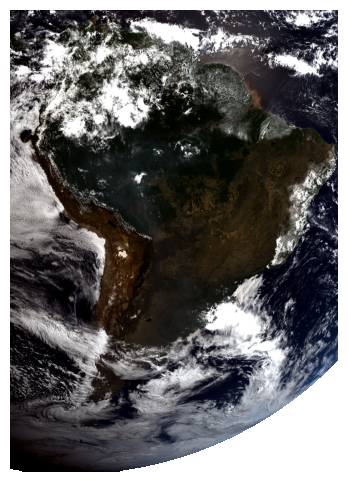

In [19]:
# Extract bands data and plot
band_r = bands1to6_reflc.band2_refl.values
band_g = bands1to6_reflc.bandSG_refl.values
band_b = bands1to6_reflc.band1_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

## Plot bands composition
plot_rgb(array, p = 5) # NOTE: try different "p" if necessary

## Band 7 to bright temperature

In [20]:
# Open band and read band 7
print(all_filles_sorted[6]) # check band 7 path
goes_band7 = xr.open_dataset(directory_path+all_filles_sorted[6], decode_coords="all")

OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc


In [22]:
# Bands algebra computing
arg_log = (goes_band7.planck_fk1/goes_band7.Rad)+1
num_bt = (goes_band7.planck_fk2/np.log(arg_log))-goes_band7.planck_bc1
den_bt = goes_band7.planck_bc2

band7_toBT = num_bt/den_bt

# Resample band 7
band7_toBT = band7_toBT.rio.write_crs(goes_band.Rad.rio.crs)
print('Input shape:', band7_toBT.shape)
band7_toBT_res = resampling_xarray(band_org, band7_toBT) # resample to band 1 (band_org)
print('Output shape:', band7_toBT_res.shape)

/usr/local/lib/python3.12/dist-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)


Input shape: (5424, 5424)
Output shape: (6786, 4822)


In [23]:
# Store bands in a new dataset
bands_1to7 = bands1to6_reflc.copy() # make a copy of the dataset with bands 1-6

# Store BT band in the dataset
bands_1to7['band7_BT'] = xr.DataArray(band7_toBT_res.values, coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
bands_1to7['band7_BT'] = bands_1to7['band7_BT'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
#bands_1to7

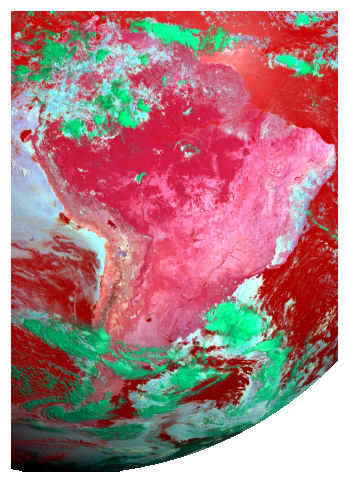

In [24]:
# Extract bands data and plot
band_r = bands_1to7.band7_BT.values
band_g = bands_1to7.band6_refl.values
band_b = bands_1to7.band5_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

## Plot bands composition
plot_rgb(array, p = 3)

## Map fire event (Córdoba)

In [ ]:
# Reproject to EPSG 4326
## NOTE: GOES data must be first converted from scan angles to meters

h = bands_1to7.band7_BT.rio.crs.to_dict()["h"] # Get satellite height (h) value

bands1to7_meters = bands_1to7.assign_coords(
    x = bands_1to7.x * h,
    y = bands_1to7.y * h
)

#bands1to7_latlon = bands1to7_latlon.rio.reproject("EPSG:4326")

In [ ]:
# Select data according to a bounding box
xmin, xmax, ymax, ymin = 889647.1495, 1041986.1762,-3316993.1354,-3158802.4175
bands1to7_fire = bands1to7_meters.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))

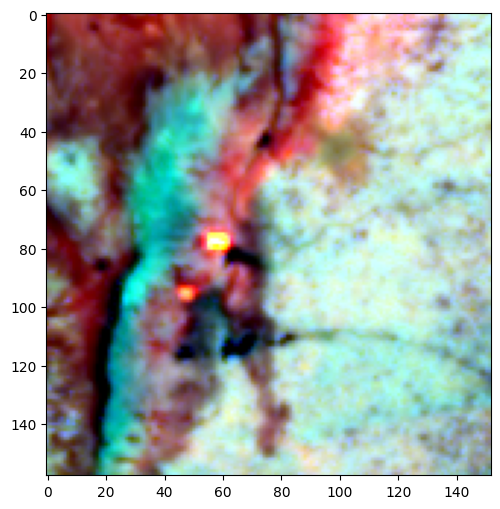

In [ ]:
# Extract bands data and plot
band_r = bands1to7_fire.band7_BT.values
band_g = bands1to7_fire.band6_refl.values
band_b = bands1to7_fire.band5_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

plot_rgb(array, p = 3)

In [ ]:
# Reproject and save data as netcdf
bands1to7_fire_latlon = bands1to7_fire.rio.reproject("EPSG:4326")
bands1to7_fire_latlon.to_netcdf('fire_event_goes.nc')